<h1 style="text-align:center;">Ito Calculus<br></h1>
<div style="text-align:center;">Ariel Kalingking</div>
<div style="text-align:center;">akalingking@gmail.com</div>
<div style="text-align:center;">Appendix: Python Code</div>

In [11]:
import math
import numpy as np
import statsmodels.api as sm
import logging
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd

plt_inline_enable = False # Turn this off when running makefile
imagepath = "../paper/figures/"
figsize = (4,3)
fontbig = 8
fontmed = 7
fontsmall = 6

matplotlib.use('TkAgg')
logging.getLogger().setLevel(logging.ERROR)
if plt_inline_enable:
    %matplotlib inline

In [9]:
np.random.seed(42)       # For reproducible paths
T = 1.0                  # Time horizon (1 year)
N = 252                  # Time steps (trading days)
dt = T / N               # Time interval
# Price parameters
S0 = 100.0               # Initial stock price
mu = 0.10                # Expected annual return (drift)
sigma = 0.30             # Annual volatility

# Vectors
dW = np.zeros(N)
time = np.linspace(0, T, N)
S = np.zeros(N)
Y = np.zeros(N)
# Initialize
S[0] = S0
Y[0] = np.log(S0)

# Simulate
for i in range(N-1):
    # Generate the brownian step
    dW[i] = np.sqrt(dt) * np.random.randn()
    # Underlying Stock SDE: dS = mu * S * dt + sigma * S * dW
    dS = mu * S[i] * dt + sigma * S[i] * dW[i]
    S[i+1] = S[i] + dS
    # Ito's Lemma Applied Log SDE: dY = (mu - 0.5 * sigma^2) * dt + sigma * dW
    dY = (mu - 0.5 * sigma**2) * dt + sigma * dW[i]
    Y[i+1] = Y[i] + dY

# 5. Verify
# If Ito's Lemma holds, Y_simulated should exactly equal ln(S_simulated)
Y_exact = np.log(S)

# Print out a quick snapshot verification
#print(f"Final Simulated S_T: {S[-1]:.4f}")
#print(f"Final Ito's Y_T:     {Y[-1]:.4f}")
#print(f"Analytical ln(S_T):  {Y_exact[-1]:.4f}")
#print(f"Error:               {abs(Y[-1] - Y_exact[-1])/Y_exact[-1] * 100:.3f}%")

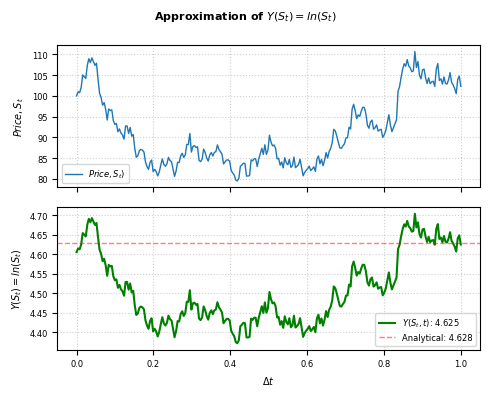

In [10]:
fig, (ax1,ax2) =  plt.subplots(2,1,figsize=(5,4), sharex=True)
ax1.plot(time, S, label=r"$Price, S_t)$", linewidth=1)
ax1.set_ylabel('$Price, S_t$', fontsize=fontmed)
ax1.legend(loc="best",fontsize=fontsmall)
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.tick_params(axis='both', which='major', labelsize=fontsmall) 

ax2.plot(time, Y, label=f"$Y(S_t,t)$: {Y[-1]:.3f}", color="green", linewidth=1.5)
#ax2.plot(time[0], X_0, 'o')
#ax2.plot(time[-1], f_Xt[-1], 'o')
ax2.axhline(Y_exact[-1], color="red", linestyle="--",
            linewidth=1.0, alpha=0.5, label=f"Analytical: {Y_exact[-1]:.3f}")
ax2.set_ylabel('$Y(S_t)=ln(S_t)$', fontsize=fontmed)
ax2.legend(loc="best",fontsize=fontsmall)
ax2.grid(True, linestyle=':', alpha=0.6)

plt.suptitle("Approximation of $Y(S_t) = ln(S_t)$", fontsize=fontbig, fontweight="bold")
plt.tick_params(axis='both', which='major', labelsize=fontsmall) 
plt.xlabel('$\Delta t$', fontsize=fontmed)
plt.tight_layout()
plt.savefig(imagepath+"itos_lemma_2.pdf", bbox_inches="tight")
if plt_inline_enable:
    plt.show()